In [70]:
import redback
from redback.constants import day_to_s
from redback.model_library import all_models_dict
import numpy as np
import pandas as pd

In [2]:
import pandas as pd

file_path = '/tf/astrodados2/phelipedata2/WHISPER/redback/forcedphotometry_req00459147_lc.txt'

rows = []

with open(file_path, 'r') as file:
    for line in file:
        line = line.strip()

        # skip comments and separators
        if not line or line.startswith('#') or line.startswith('-'):
            continue

        columns = line.split()
        rows.append(columns)

column_names = [
    'index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci', 'sciinpseeing',
    'scibckgnd', 'scisigpix', 'zpmaginpsci', 'zpmaginpsciunc', 'zpmaginpscirms',
    'clrcoeff', 'clrcoeffunc', 'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2',
    'diffmaglim', 'zpdiff', 'programid', 'jd', 'rfid', 'diffimgstatus', 
    'forcediffimflux', 'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq', 
    'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap', 'aperturecorr',
    'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc', 'nearestrefchi', 
    'nearestrefsharp', 'refjdstart', 'refjdend', 'procstatus'
]

# remove header row if present
if rows and rows[0] == column_names:
    rows = rows[1:]

df = pd.DataFrame(rows, columns=column_names)

# numeric conversion — critical for correct photometric uncertainty propagation
numeric_cols = ['jd', 'forcediffimflux', 'forcediffimfluxunc', 'zpdiff']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['filter'] = df['filter'].astype('string')

# remove rows where essential measurement quantities are invalid
df = df.dropna(subset=numeric_cols)
 # Keep only positive flux
df = df[df['forcediffimflux'] > 0]

# Magnitude and error
df['apparent_mag'] = -2.5 * np.log10(df['forcediffimflux']) + df['zpdiff']
df['apparent_magerr'] = 1.0857 * df['forcediffimfluxunc'] / df['forcediffimflux']
df['MJD'] = df['jd'] - 2400000.5
# Average by JD
df_avg = df.groupby(['filter','MJD'], as_index=False).agg({
    'apparent_mag': 'mean',
    'apparent_magerr': 'mean'
})
df_avg

,filter,MJD,apparent_mag,apparent_magerr
0,ZTF_g,59671.422917,24.080494,2.484510
1,ZTF_g,59674.410139,22.699086,1.659173
2,ZTF_g,59676.302107,22.441473,1.220034
3,ZTF_g,59676.325278,24.168050,6.114729
4,ZTF_g,59678.304803,23.302092,2.417569
...,...,...,...,...
304,ZTF_r,60043.361736,21.097862,0.408618
305,ZTF_r,60053.219213,21.120564,0.433908
306,ZTF_r,60053.241227,20.497425,0.278202
307,ZTF_r,60059.202697,21.187758,0.350245


Best-fit parameters:
r0 = 22.5361 ± 0.1110
A  = -3.5250 ± 0.4937
t0 = 59886.9089 ± 3.9886
tg = 34.7266 ± 30.5988
te = 18.6484 ± 4.7752


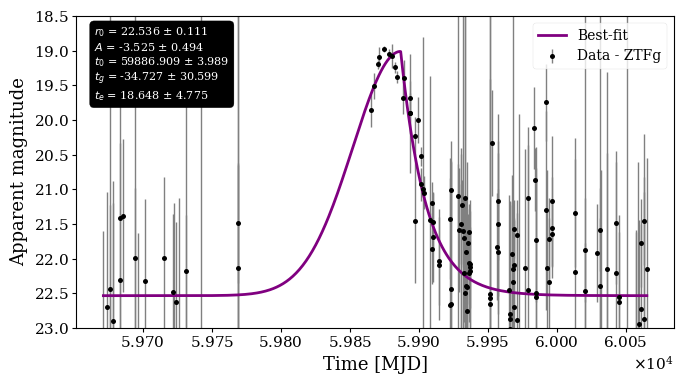

In [37]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False
df_avg_g = df_avg[df_avg['filter']=='ZTF_g']
tmin = 59880 - 400
tmax = 59880 + 400
maskg = (df_avg_g['MJD'] >= tmin) & (df_avg_g['MJD'] <= tmax)

df_avg_r = df_avg[df_avg['filter']=='ZTF_r']
tmin = 59880 - 200
tmax = 59880 + 200
maskr = (df_avg_r['MJD'] >= tmin) & (df_avg_r['MJD'] <= tmax)




time_mjd0  = df_avg_g['MJD'].values[mask]
mag0 = df_avg_g['apparent_mag'].values[mask]
mag_err0 = df_avg_g['apparent_magerr'].values[mask]



# --- Model definition ---
def gaussian_rise_exp_decay(t, r0, A, t0, tg, te):
    """Gaussian rise - exponential decay model."""
    t = np.array(t)
    y = np.empty_like(t)
    mask_rise = t <= t0
    mask_decay = t > t0

    y[mask_rise]  = r0 + A * np.exp(-((t[mask_rise] - t0)**2) / (2 * tg**2))
    y[mask_decay] = r0 + A * np.exp(-(t[mask_decay] - t0) / te)
    return y

def initial_guess(t, y):
    r0 = np.median(y)
    A = np.min(y) - r0          # assuming flare brightens (smaller mag)
    t0 = t[np.argmin(y)]
    tg = (t.max() - t.min()) / 10
    te = tg
    return [r0, A, t0, tg, te]

p0 = initial_guess(time_mjd0, mag0)

# --- Fit the model ---
popt, pcov = curve_fit(gaussian_rise_exp_decay, time_mjd0, mag0, p0=p0)

# --- Extract best-fit parameters ---
r0, A, t0, tg, te = popt
perr = np.sqrt(np.diag(pcov))

print("Best-fit parameters:")
print(f"r0 = {r0:.4f} ± {perr[0]:.4f}")
print(f"A  = {A:.4f} ± {perr[1]:.4f}")
print(f"t0 = {t0:.4f} ± {perr[2]:.4f}")
print(f"tg = {tg:.4f} ± {perr[3]:.4f}")
print(f"te = {te:.4f} ± {perr[4]:.4f}")

# --- Plot ---
t_fit = np.linspace(np.min(time_mjd0), np.max(time_mjd0), 500)
mag_fit = gaussian_rise_exp_decay(t_fit, *popt)

plt.figure(figsize=(7,4))
plt.errorbar(
    time_mjd0, mag0, yerr=mag_err0, fmt='o', color='k', ecolor='gray',
    elinewidth=1, capsize=2, label='Data - ZTFg'
)
plt.plot(t_fit, mag_fit, ls='-', label='Best-fit', lw=2, color='purple')
#plt.axvline(x=t0, color='red',alpha=0.2,lw=2, ls='--')
plt.gca().invert_yaxis()  # magnitudes: smaller = brighter
plt.xlabel('Time [MJD]')
plt.ylabel('Apparent magnitude')


# # Best-fit analytic TDE
# out_best = redback.transient_models.tde_models.tde_analytical(time, **TDE_best)
# plt.plot(time+59865.6697106, out_best, alpha=1, color='orange', lw=3,
#          label='Best-fit analytic TDE')

# out_sne_g = redback.transient_models.supernova_models.shock_cooling_and_arnett(time, **SNE_best_g)
# plt.plot(time+59865.6697106, out_sne_g, color='#0072B2', lw=2.5, alpha=0.9,
#          label='Best-fit SNe Shock+Arnett (ztf-g)')


param_text = (
    f"$r_0$ = {r0:.3f} ± {perr[0]:.3f}\n"
    f"$A$ = {A:.3f} ± {perr[1]:.3f}\n"
    f"$t_0$ = {t0:.3f} ± {perr[2]:.3f}\n"
    f"$t_g$ = {-tg:.3f} ± {perr[3]:.3f}\n"
    f"$t_e$ = {te:.3f} ± {perr[4]:.3f}"
)

plt.text(
    0.03, 0.97, param_text,
    transform=plt.gca().transAxes, fontsize=8,
    va='top', ha='left', color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=1.0)
)

plt.ylim(23,18.5)
plt.legend()
plt.tight_layout()
#plt.savefig('flare_like_fit.png',dpi=300)
plt.show()


Best-fit parameters:
r0 = 22.5361 ± 0.1110
A  = -3.5250 ± 0.4937
t0 = 59886.9089 ± 3.9886
tg = 34.7266 ± 30.5988
te = 18.6484 ± 4.7752


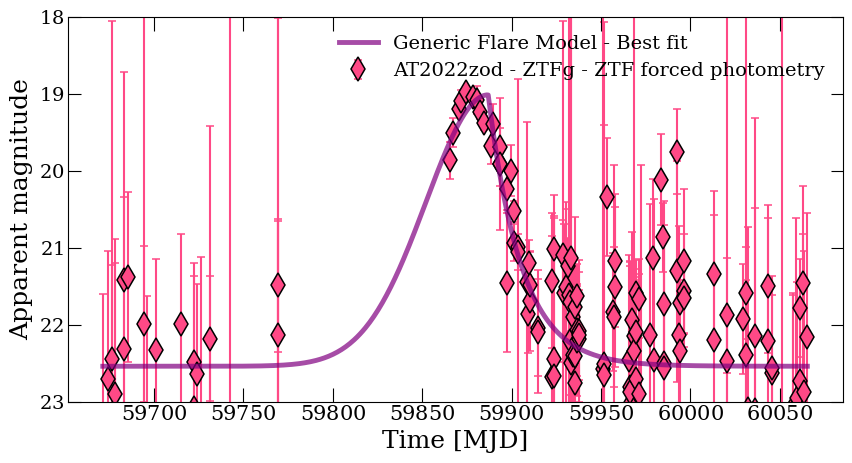

In [38]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# # Load each filter
# data_g = load_filter_data('ZTF18aarlhfw.csv', 'zg')
# data_r = load_filter_data('ZTF18aarlhfw.csv', 'zr')
# time_mjd0  = data_g['mjd']
# mag0 = data_g['mag']
# mag_err0 = data_g['magerr']

# --- Fit both ---
def fit_lightcurve(data,mask):
    time = data['MJD'].values[mask]
    mag = data['apparent_mag'].values[mask]
    mag_err = data['apparent_magerr'].values[mask]
    p0 = initial_guess(time, mag)
    popt, pcov = curve_fit(gaussian_rise_exp_decay, time, mag, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, time, mag, mag_err

popt_g, perr_g, time_g, mag_g, err_g = fit_lightcurve(df_avg_g,maskg)


# # --- Model definition ---
# def gaussian_rise_exp_decay(t, r0, A, t0, tg, te):
#     """Gaussian rise - exponential decay model."""
#     t = np.array(t)
#     y = np.empty_like(t)
#     mask_rise = t <= t0
#     mask_decay = t > t0

#     y[mask_rise]  = r0 + A * np.exp(-((t[mask_rise] - t0)**2) / (2 * tg**2))
#     y[mask_decay] = r0 + A * np.exp(-(t[mask_decay] - t0) / te)
#     return y

# def initial_guess(t, y):
#     r0 = np.median(y)
#     A = np.min(y) - r0          # assuming flare brightens (smaller mag)
#     t0 = t[np.argmin(y)]
#     tg = (t.max() - t.min()) / 10
#     te = tg
#     return [r0, A, t0, tg, te]

# p0 = initial_guess(time_mjd0, mag0)

# # --- Fit the model ---
# popt, pcov = curve_fit(gaussian_rise_exp_decay, time_mjd0, mag0, p0=p0)

# --- Extract best-fit parameters ---
r0, A, t0, tg, te = popt_g
perr = perr_g

print("Best-fit parameters:")
print(f"r0 = {r0:.4f} ± {perr[0]:.4f}")
print(f"A  = {A:.4f} ± {perr[1]:.4f}")
print(f"t0 = {t0:.4f} ± {perr[2]:.4f}")
print(f"tg = {tg:.4f} ± {perr[3]:.4f}")
print(f"te = {te:.4f} ± {perr[4]:.4f}")

# --- Plot ---
t_fit = np.linspace(np.min(time_mjd0), np.max(time_mjd0), 500)
mag_fit = gaussian_rise_exp_decay(t_fit, *popt_g)

plt.figure(figsize=(10,5))
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10
})



plt.errorbar(time_mjd0, mag0, yerr=mag_err0, marker='d',ls='None',color="#FF4986",ms=12,mfc="#FF4986",mew=1.1, mec='black',ecolor="#FF4986", label='AT2022zod - ZTFg - ZTF forced photometry',zorder=0,   capsize=3,elinewidth=1.5)
plt.plot(t_fit, mag_fit, ls='-', label='Generic Flare Model - Best fit', lw=3.5, color='purple',zorder=1, alpha=0.7)

plt.tick_params(axis='x', which='major', labelsize=15)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')


plt.gca().invert_yaxis()  # magnitudes: smaller = brighter
plt.xlabel('Time [MJD]', fontsize=18)
plt.ylabel('Apparent magnitude', fontsize=18)
# # --- Secondary y-axis (Absolute Magnitude) ---
# ax = plt.gca()
# ax2 = ax.twinx()
# y1, y2 = ax.get_ylim()
# ax2.set_ylim(y1 - mu, y2 - mu)
# ax2.invert_yaxis()
# ax2.set_ylabel('Absolute Magnitude', fontsize=16)
# # Best-fit analytic TDE
# out_best = redback.transient_models.tde_models.tde_analytical(time, **TDE_best)
# plt.plot(time+59865.6697106, out_best, alpha=1, color='orange', lw=3,
#          label='Best-fit analytic TDE')

# out_sne_g = redback.transient_models.supernova_models.shock_cooling_and_arnett(time, **SNE_best_g)
# plt.plot(time+59865.6697106, out_sne_g, color='#0072B2', lw=2.5, alpha=0.9,
#          label='Best-fit SNe Shock+Arnett (ztf-g)')


# param_text = (
#     f"$r_0$ = {r0:.3f} ± {perr[0]:.3f}\n"
#     f"$A$ = {A:.3f} ± {perr[1]:.3f}\n"
#     f"$t_0$ = {t0:.3f} ± {perr[2]:.3f}\n"
#     f"$t_g$ = {-tg:.3f} ± {perr[3]:.3f}\n"
#     f"$t_e$ = {te:.3f} ± {perr[4]:.3f}"
# )

# plt.text(
#     0.03, 0.97, param_text,
#     transform=plt.gca().transAxes, fontsize=8,
#     va='top', ha='left', color='white',
#     bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=1.0)
# )
plt.ticklabel_format(style='plain', axis='x')
plt.ylim(23,18)
plt.legend(fontsize=14,frameon=False)
plt.savefig('ZTF18_coin_flare_ztfgr_new_g0.pdf', dpi=400,bbox_inches="tight")
#plt.savefig('flare_like_fit.png',dpi=300)
plt.show()


In [52]:
print(mu,'ztfg:',19.01-mu,'ztf_r', 18.9922-mu)

38.60846722939633 ztfg: -19.59846722939633 ztf_r -19.616267229396332


In [51]:
((22.5361-0.1)-(3.5250+0.4937))-mu

-20.19106722939633

In [54]:
-19.59846722939633 + 20.19106722939633

0.5926000000000009

In [56]:
-19.59846722939633 + 19.0036

-0.594867229396332

Best-fit parameters:
r0 = 21.7896 ± 0.1192
A  = -2.7974 ± 0.3695
t0 = 59885.2193 ± 5.8638
tg = 32.4436 ± 24.7359
te = 34.2988 ± 7.6863


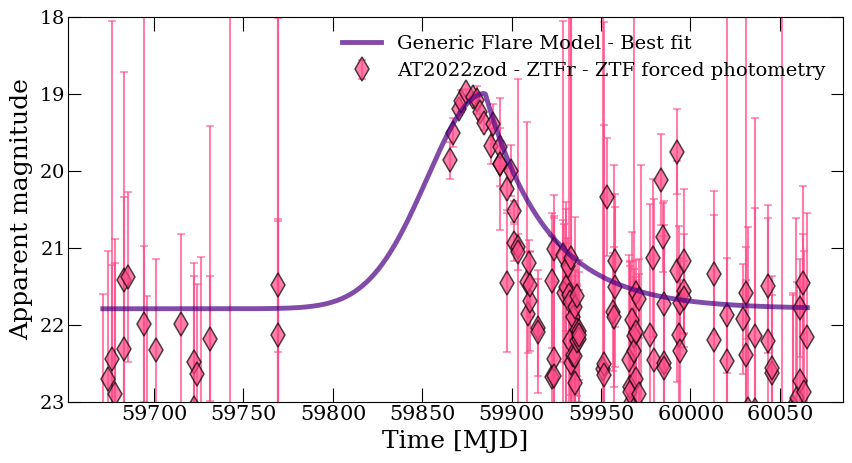

In [20]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# # Load each filter
# data_g = load_filter_data('ZTF18aarlhfw.csv', 'zg')
# data_r = load_filter_data('ZTF18aarlhfw.csv', 'zr')
# time_mjd0  = data_g['mjd']
# mag0 = data_g['mag']
# mag_err0 = data_g['magerr']

# --- Fit both ---
def fit_lightcurve(data,mask):
    time = data['MJD'].values[mask]
    mag = data['apparent_mag'].values[mask]
    mag_err = data['apparent_magerr'].values[mask]
    p0 = initial_guess(time, mag)
    popt, pcov = curve_fit(gaussian_rise_exp_decay, time, mag, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, time, mag, mag_err

popt_g, perr_g, time_g, mag_g, err_g = fit_lightcurve(df_avg_r,maskr)


# # --- Model definition ---
# def gaussian_rise_exp_decay(t, r0, A, t0, tg, te):
#     """Gaussian rise - exponential decay model."""
#     t = np.array(t)
#     y = np.empty_like(t)
#     mask_rise = t <= t0
#     mask_decay = t > t0

#     y[mask_rise]  = r0 + A * np.exp(-((t[mask_rise] - t0)**2) / (2 * tg**2))
#     y[mask_decay] = r0 + A * np.exp(-(t[mask_decay] - t0) / te)
#     return y

# def initial_guess(t, y):
#     r0 = np.median(y)
#     A = np.min(y) - r0          # assuming flare brightens (smaller mag)
#     t0 = t[np.argmin(y)]
#     tg = (t.max() - t.min()) / 10
#     te = tg
#     return [r0, A, t0, tg, te]

# p0 = initial_guess(time_mjd0, mag0)

# # --- Fit the model ---
# popt, pcov = curve_fit(gaussian_rise_exp_decay, time_mjd0, mag0, p0=p0)

# --- Extract best-fit parameters ---
r0, A, t0, tg, te = popt_g
perr = perr_g

print("Best-fit parameters:")
print(f"r0 = {r0:.4f} ± {perr[0]:.4f}")
print(f"A  = {A:.4f} ± {perr[1]:.4f}")
print(f"t0 = {t0:.4f} ± {perr[2]:.4f}")
print(f"tg = {tg:.4f} ± {perr[3]:.4f}")
print(f"te = {te:.4f} ± {perr[4]:.4f}")

# --- Plot ---
t_fit = np.linspace(np.min(time_mjd0), np.max(time_mjd0), 500)
mag_fit = gaussian_rise_exp_decay(t_fit, *popt_g)

plt.figure(figsize=(10,5))
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10
})



plt.errorbar(time_mjd0, mag0, yerr=mag_err0, marker='d',ls='None',color="#FF4986",ms=12,mfc="#FF4986",mew=1.1, mec='black',ecolor="#FF4986", label='AT2022zod - ZTFr - ZTF forced photometry',zorder=0,   capsize=3,elinewidth=1.5,alpha=0.7)
plt.plot(t_fit, mag_fit, ls='-', label='Generic Flare Model - Best fit', lw=3.5, color='indigo',zorder=1, alpha=0.7)

plt.tick_params(axis='x', which='major', labelsize=15)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')


plt.gca().invert_yaxis()  # magnitudes: smaller = brighter
plt.xlabel('Time [MJD]', fontsize=18)
plt.ylabel('Apparent magnitude', fontsize=18)
# # --- Secondary y-axis (Absolute Magnitude) ---
# ax = plt.gca()
# ax2 = ax.twinx()
# y1, y2 = ax.get_ylim()
# ax2.set_ylim(y1 - mu, y2 - mu)
# ax2.invert_yaxis()
# ax2.set_ylabel('Absolute Magnitude', fontsize=16)
# # Best-fit analytic TDE
# out_best = redback.transient_models.tde_models.tde_analytical(time, **TDE_best)
# plt.plot(time+59865.6697106, out_best, alpha=1, color='orange', lw=3,
#          label='Best-fit analytic TDE')

# out_sne_g = redback.transient_models.supernova_models.shock_cooling_and_arnett(time, **SNE_best_g)
# plt.plot(time+59865.6697106, out_sne_g, color='#0072B2', lw=2.5, alpha=0.9,
#          label='Best-fit SNe Shock+Arnett (ztf-g)')


# param_text = (
#     f"$r_0$ = {r0:.3f} ± {perr[0]:.3f}\n"
#     f"$A$ = {A:.3f} ± {perr[1]:.3f}\n"
#     f"$t_0$ = {t0:.3f} ± {perr[2]:.3f}\n"
#     f"$t_g$ = {-tg:.3f} ± {perr[3]:.3f}\n"
#     f"$t_e$ = {te:.3f} ± {perr[4]:.3f}"
# )

# plt.text(
#     0.03, 0.97, param_text,
#     transform=plt.gca().transAxes, fontsize=8,
#     va='top', ha='left', color='white',
#     bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=1.0)
# )
plt.ticklabel_format(style='plain', axis='x')
plt.ylim(23,18)
plt.legend(fontsize=14,frameon=False)
plt.savefig('ZTF18_coin_flare_ztfgr_new_R0.pdf', dpi=400,bbox_inches="tight")
#plt.savefig('flare_like_fit.png',dpi=300)
plt.show()


In [25]:
21.7896-2.7974

18.9922

# Absolute magnitude peak calculations:

In [40]:
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
z = 0.11
mu = 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
print(mu,'ztfg:',19.01-mu,'ztf_r', 18.9922-mu)

38.60846722939633 ztfg: -19.59846722939633 ztf_r -19.616267229396332


# Rise and Decay plot 

In [21]:
import redback
from redback.constants import day_to_s
from redback.model_library import all_models_dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['text.usetex'] = False
from astropy.cosmology import Planck18 as cosmo
import glob

df_with_abs = pd.read_csv('df_decay_with_errors.csv', sep=';')

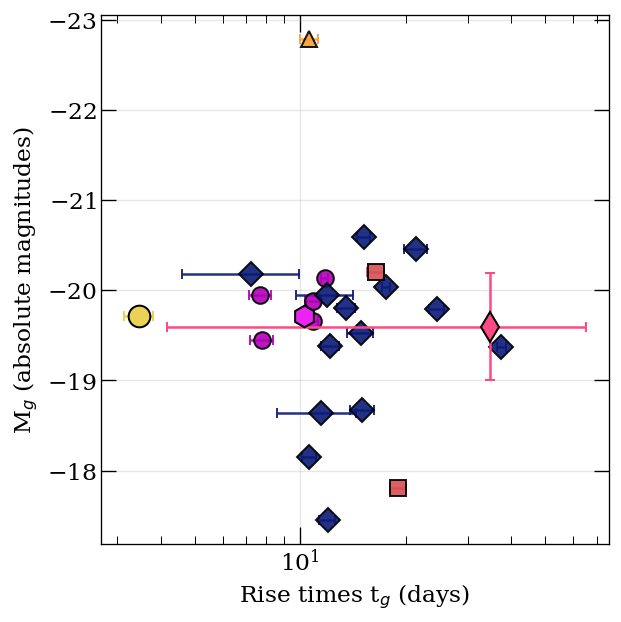

In [58]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "M_abs"])
# Ensure uncertainty columns exist
if "rise_timescale_err" not in df_rise.columns:
    df_rise = df_rise.merge(df_all[["IAU", "rise_timescale_err"]], on="IAU", how="left")
if "decay_timescale_err" not in df_decay.columns:
    df_decay = df_decay.merge(df_all[["IAU", "decay_timescale_err"]], on="IAU", how="left")

# ============================================================
# USE THE TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},      # diamond, dark blue
    "TDE-H":           {"marker": "o", "color": "#B000B7"},      # circle, magenta
    "TDE-He":          {"marker": "s", "color": "#D54F52"},      # square, red-pink
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}       # triangle, orange
}

subtypes = list(tde_styles.keys())

plt.figure(dpi=120, figsize=(5,5))

for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    
    plt.errorbar(
        group["rise_timescale"],
        group["M_abs"],
        xerr=group["rise_timescale_err"],
        yerr=None,
        marker=style["marker"],
        linestyle="none",          # avoids line connecting points
        mfc=style["color"],        # marker face color
        mec="black",               # marker edge color
        mew=1.2,                   # edge width
        ecolor=style["color"],
        capsize=3,
        markersize=10,
        elinewidth=1.5,
        alpha=0.9
    )


    
# SPECIAL OBJECTS (rise)
##AT2022zod
plt.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
##AT2024tvd
plt.errorbar(10.21, -19.71, marker='h',xerr=0.34, color="#EB24F4", mec="black",mew=1.2,ecolor= "#EB24F4", zorder=500,capsize=3,markersize=13,elinewidth=1.5, label='AT2024tvd')
##'AT2020neh'
plt.errorbar(3.47, -19.72, marker='o', xerr=0.33, color="#EBD155", mec="black",mew=1.2,ecolor= "#EBD155", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2020neh')

# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = []

# TDE subtype legend entries
for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=style["marker"],
            color="white",
            markerfacecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=10,
            label=subtype
        )
    )

# Special objects
special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"}
}

for name, info in special_points.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=info["marker"],
            color="white",
            markerfacecolor=info["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=12,
            label=name
        )
    )

# plt.legend(
#     handles=legend_elements,
#     fontsize=12,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.85,
#     loc="upper left",
#     bbox_to_anchor=(1.0, 1.0),   # move legend OUTSIDE
#     borderaxespad=1.5
# )
plt.tight_layout()

plt.tick_params(axis='x', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')

plt.xscale("log")
plt.ylabel(r"M$_g$ (absolute magnitudes)", fontsize=14)
plt.xlabel(r"Rise times t$_g$ (days)", fontsize=14)
plt.grid(alpha=0.3)
plt.gca().invert_yaxis()
plt.savefig('ztfFP_rise_tde.png',dpi=300)

plt.show()

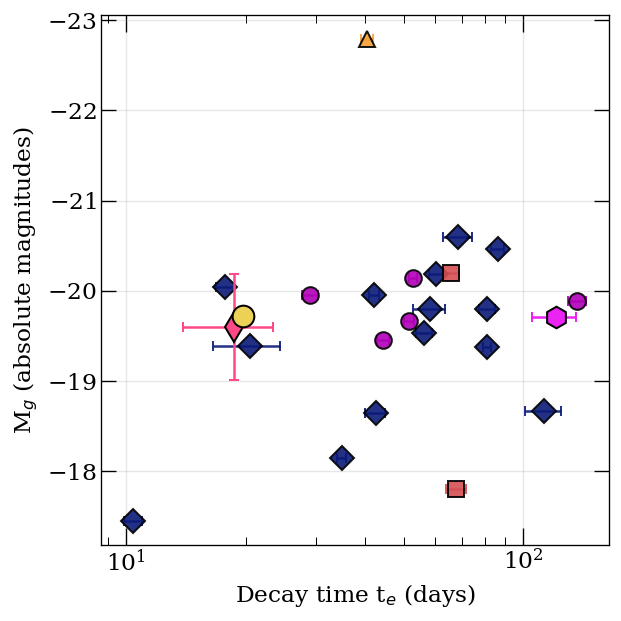

In [59]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "M_abs"])
# Ensure uncertainty columns exist
if "rise_timescale_err" not in df_rise.columns:
    df_rise = df_rise.merge(df_all[["IAU", "rise_timescale_err"]], on="IAU", how="left")
if "decay_timescale_err" not in df_decay.columns:
    df_decay = df_decay.merge(df_all[["IAU", "decay_timescale_err"]], on="IAU", how="left")

# ============================================================
# USE THE TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},      # diamond, dark blue
    "TDE-H":           {"marker": "o", "color": "#B000B7"},      # circle, magenta
    "TDE-He":          {"marker": "s", "color": "#D54F52"},      # square, red-pink
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}       # triangle, orange
}

subtypes = list(tde_styles.keys())

plt.figure(dpi=120,figsize=(5,5))

for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    
    plt.errorbar(
        group["decay_timescale"],
        group["M_abs"],
        xerr=group["decay_timescale_err"],
        yerr=None,
        marker=style["marker"],
        linestyle="none",          # avoids line connecting points
        mfc=style["color"],        # marker face color
        mec="black",               # marker edge color
        mew=1.2,                   # edge width
        ecolor=style["color"],
        capsize=3,
        markersize=10,
        elinewidth=1.5,
        alpha=0.9
    )


##AT2022zod
plt.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
##AT2024tvd
plt.errorbar(120.719, -19.71, marker='h',xerr=15.43, color="#EB24F4", mec="black",mew=1.2,ecolor= "#EB24F4", zorder=500,capsize=3,markersize=13,elinewidth=1.5, label='AT2024tvd')
##'AT2020neh'
plt.errorbar(19.66, -19.72, marker='o', xerr=0.90, color="#EBD155", mec="black",mew=1.2,ecolor= "#EBD155", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2020neh')


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = []

# TDE subtype legend entries
for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=style["marker"],
            color="white",
            markerfacecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=10,
            label=subtype
        )
    )

# Special objects
special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"}
}

for name, info in special_points.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=info["marker"],
            color="white",
            markerfacecolor=info["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=12,
            label=name
        )
    )

# plt.legend(
#     handles=legend_elements,
#     fontsize=12,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.85,
#     loc="upper left",
#     bbox_to_anchor=(1.0, 1.0),   # move legend OUTSIDE
#     borderaxespad=1.5
# )
plt.tight_layout()

plt.tick_params(axis='x', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')

plt.xscale("log")
plt.ylabel(r"M$_g$ (absolute magnitudes)", fontsize=14)
plt.xlabel(r"Decay time t$_e$ (days)", fontsize=14)
plt.grid(alpha=0.3)
plt.gca().invert_yaxis()
plt.savefig('ztffp_decay_tde.png',dpi=300)

plt.show()

# Duration plots

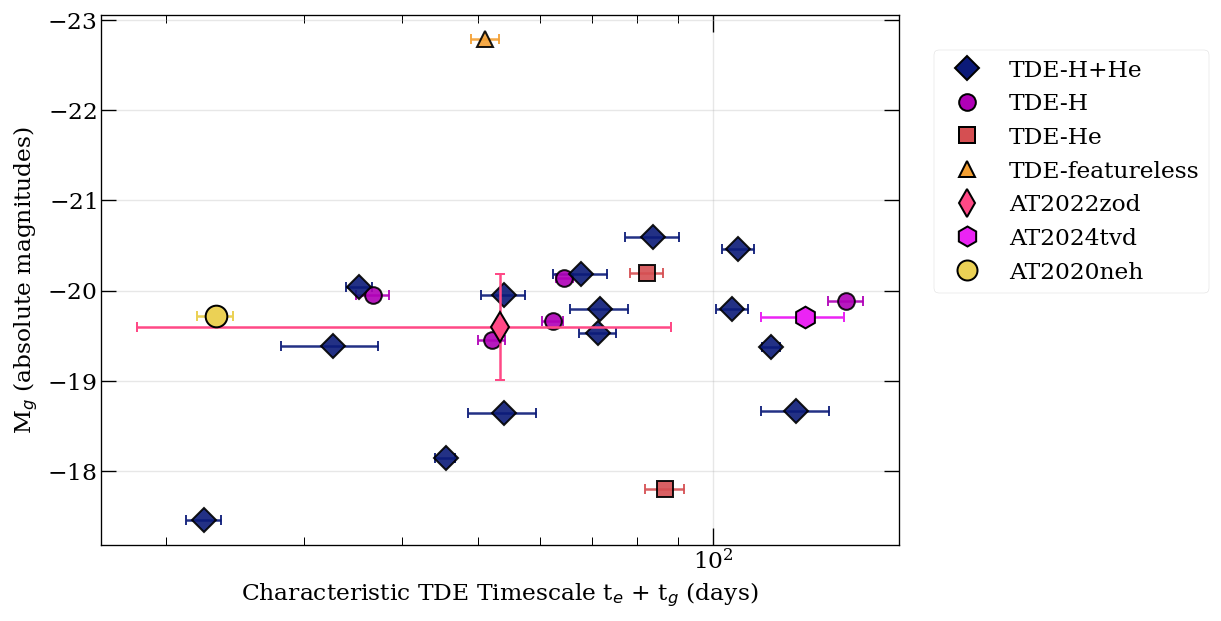

In [60]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "M_abs"])
# Ensure uncertainty columns exist
if "rise_timescale_err" not in df_rise.columns:
    df_rise = df_rise.merge(df_all[["IAU", "rise_timescale_err"]], on="IAU", how="left")
if "decay_timescale_err" not in df_decay.columns:
    df_decay = df_decay.merge(df_all[["IAU", "decay_timescale_err"]], on="IAU", how="left")

# ============================================================
# USE THE TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},      # diamond, dark blue
    "TDE-H":           {"marker": "o", "color": "#B000B7"},      # circle, magenta
    "TDE-He":          {"marker": "s", "color": "#D54F52"},      # square, red-pink
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}       # triangle, orange
}

subtypes = list(tde_styles.keys())

plt.figure(dpi=120, figsize=(10,5))

for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    
    plt.errorbar(
        group["decay_timescale"]+group["rise_timescale"],
        group["M_abs"],
        xerr=group["decay_timescale_err"]+group["rise_timescale_err"],
        yerr=None,
        marker=style["marker"],
        linestyle="none",          # avoids line connecting points
        mfc=style["color"],        # marker face color
        mec="black",               # marker edge color
        mew=1.2,                   # edge width
        ecolor=style["color"],
        capsize=3,
        markersize=10,
        elinewidth=1.5,
        alpha=0.9
    )


##At2022zod
# plt.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# plt.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')

plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
##AT2024tvd
plt.errorbar(120.719+10.21, -19.71, marker='h',xerr=15.43+0.34, color="#EB24F4", mec="black",mew=1.2,ecolor= "#EB24F4", zorder=500,capsize=3,markersize=13,elinewidth=1.5, label='AT2024tvd')
##'AT2020neh'
plt.errorbar(19.66+3.47, -19.72, marker='o', xerr=0.90+0.33, color="#EBD155", mec="black",mew=1.2,ecolor= "#EBD155", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2020neh')


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = []

# TDE subtype legend entries
for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=style["marker"],
            color="white",
            markerfacecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=10,
            label=subtype
        )
    )

# Special objects
special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"}
}

for name, info in special_points.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=info["marker"],
            color="white",
            markerfacecolor=info["color"],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            markersize=12,
            label=name
        )
    )

plt.legend(
    handles=legend_elements,
    fontsize=14,
    frameon=True,
    fancybox=True,
    framealpha=0.85,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),   # move legend OUTSIDE
    borderaxespad=1.5
)
plt.tight_layout()

plt.tick_params(axis='x', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')

plt.xscale("log")
plt.ylabel(r"M$_g$ (absolute magnitudes)", fontsize=14)
plt.xlabel(r"Characteristic TDE Timescale t$_e$ + t$_g$ (days)", fontsize=14)
plt.grid(alpha=0.3)
plt.gca().invert_yaxis()
plt.savefig('ztfFP_duration_tde.png',dpi=300)
plt.show()

# All plots combined:

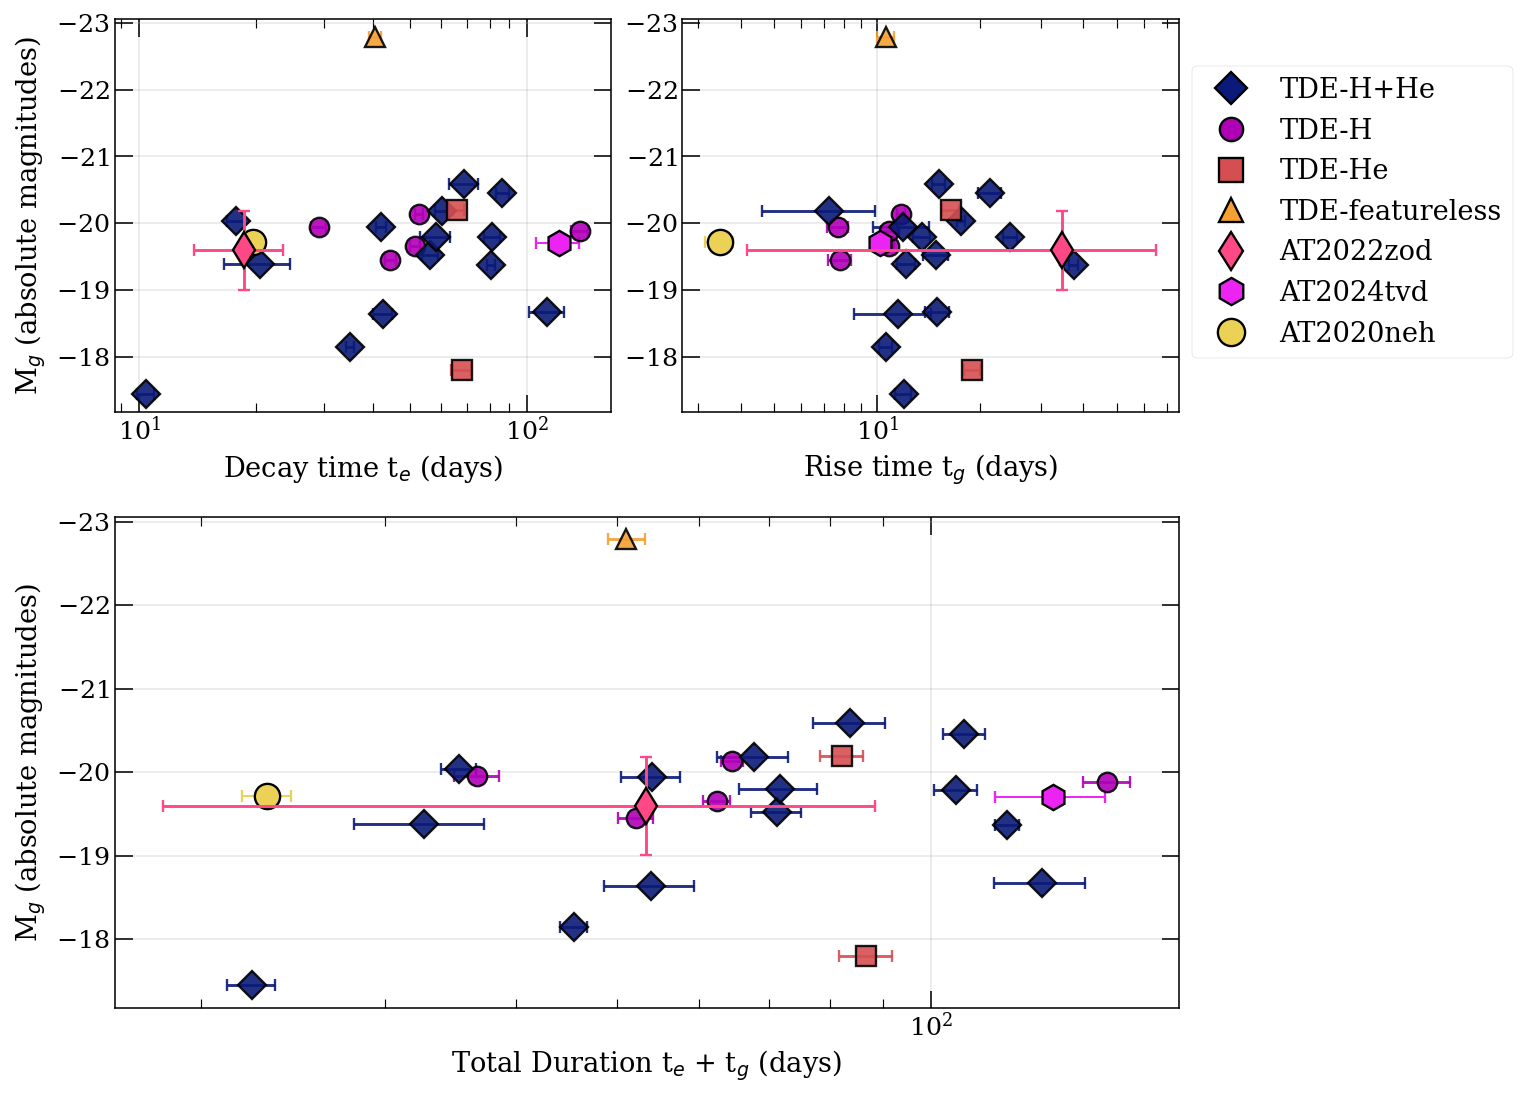

In [61]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA (same for all panels)
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "M_abs"])

# Ensure uncertainty columns exist
if "rise_timescale_err" not in df_rise.columns:
    df_rise = df_rise.merge(df_all[["IAU", "rise_timescale_err"]], on="IAU", how="left")
if "decay_timescale_err" not in df_decay.columns:
    df_decay = df_decay.merge(df_all[["IAU", "decay_timescale_err"]], on="IAU", how="left")

# ============================================================
# TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},
    "TDE-H":           {"marker": "o", "color": "#B000B7"},
    "TDE-He":          {"marker": "s", "color": "#D54F52"},
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}
}

special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"}
}

# ============================================================
# FIGURE LAYOUT (2 rows, 2 cols; bottom spans both)
# ============================================================
fig = plt.figure(figsize=(10, 8), dpi=140)

# Grid:
# ┌───────────────┬───────────────┐
# │   Decay       │    Rise        │
# ├───────────────┴───────────────┤
# │          Duration              │
# └────────────────────────────────┘

gs = fig.add_gridspec(2, 2, height_ratios=[0.8, 1.0])
ax_decay = fig.add_subplot(gs[0, 0])
ax_rise  = fig.add_subplot(gs[0, 1])
ax_dur   = fig.add_subplot(gs[1, :])

# ============================================================
# 1) DECAY PANEL
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_decay.errorbar(
        group["decay_timescale"],
        group["M_abs"],
        xerr=group["decay_timescale_err"],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Add special objects
ax_decay.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5)
# plt.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
#plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# ax_decay.errorbar(15.44, -20.34, xerr=2.38, marker='d', mfc="#FF4986",
#                   mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)

ax_decay.errorbar(120.719, -19.71, xerr=15.43, marker='h', mfc="#EB24F4",
                  mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)

ax_decay.errorbar(19.66, -19.72, xerr=0.90, marker='o', mfc="#EBD155",
                  mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_decay.set_xscale("log")
ax_decay.set_ylabel(r"M$_g$ (absolute magnitudes)", fontsize=14)
ax_decay.set_xlabel(r"Decay time t$_e$ (days)", fontsize=14)
ax_decay.invert_yaxis()
ax_decay.grid(alpha=0.3)

# formatting
ax_decay.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_decay.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)


# ============================================================
# 2) RISE PANEL
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_rise.errorbar(
        group["rise_timescale"],
        group["M_abs"],
        xerr=group["rise_timescale_err"],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Add special objects
ax_rise.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
#plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# ax_rise.errorbar(13.24, -20.34, xerr=3.68, marker='d', mfc="#FF4986",
#                  mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)
ax_rise.errorbar(10.21, -19.71, xerr=0.34, marker='h', mfc="#EB24F4",
                 mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)
ax_rise.errorbar(3.47, -19.72, xerr=0.33, marker='o', mfc="#EBD155",
                 mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_rise.set_xscale("log")
ax_rise.set_xlabel(r"Rise time t$_g$ (days)", fontsize=14)
ax_rise.invert_yaxis()
ax_rise.grid(alpha=0.3)

ax_rise.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_rise.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)


# ============================================================
# 3) DURATION PANEL (t_e + t_g)
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_dur.errorbar(
        group["rise_timescale"] + group["decay_timescale"],
        group["M_abs"],
        xerr=group["rise_timescale_err"] + group["decay_timescale_err"],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Add special objects
ax_dur.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# ax_dur.errorbar(13.24+15.44, -20.34, xerr=3.68+2.38, marker='d',
#                 mfc="#FF4986", mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)
ax_dur.errorbar(10.21+120.719, -19.71, xerr=0.34+15.43, marker='h',
                mfc="#EB24F4", mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)
ax_dur.errorbar(3.47+19.66, -19.72, xerr=0.33+0.90, marker='o',
                mfc="#EBD155", mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_dur.set_xscale("log")
ax_dur.set_xlabel(r"Total Duration t$_e$ + t$_g$ (days)", fontsize=14)
ax_dur.set_ylabel(r"M$_g$ (absolute magnitudes)", fontsize=14)
ax_dur.invert_yaxis()
ax_dur.grid(alpha=0.3)

ax_dur.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_dur.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)

# ============================================================
# SHARED LEGEND (placed on the right)
# ============================================================
legend_elements = []

for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=style["marker"],
               color="white",
               markerfacecolor=style["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=12,
               label=subtype)
    )

for name, info in special_points.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=info["marker"],
               color="white",
               markerfacecolor=info["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=14,
               label=name)
    )

fig.legend(
    handles=legend_elements,
    fontsize=14,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    loc="center left",
    bbox_to_anchor=(0.85, 0.8)
)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # leave space for the legend
plt.savefig('ztfFP_all_tde_timescale.pdf',dpi=400,bbox_inches="tight")
plt.show()


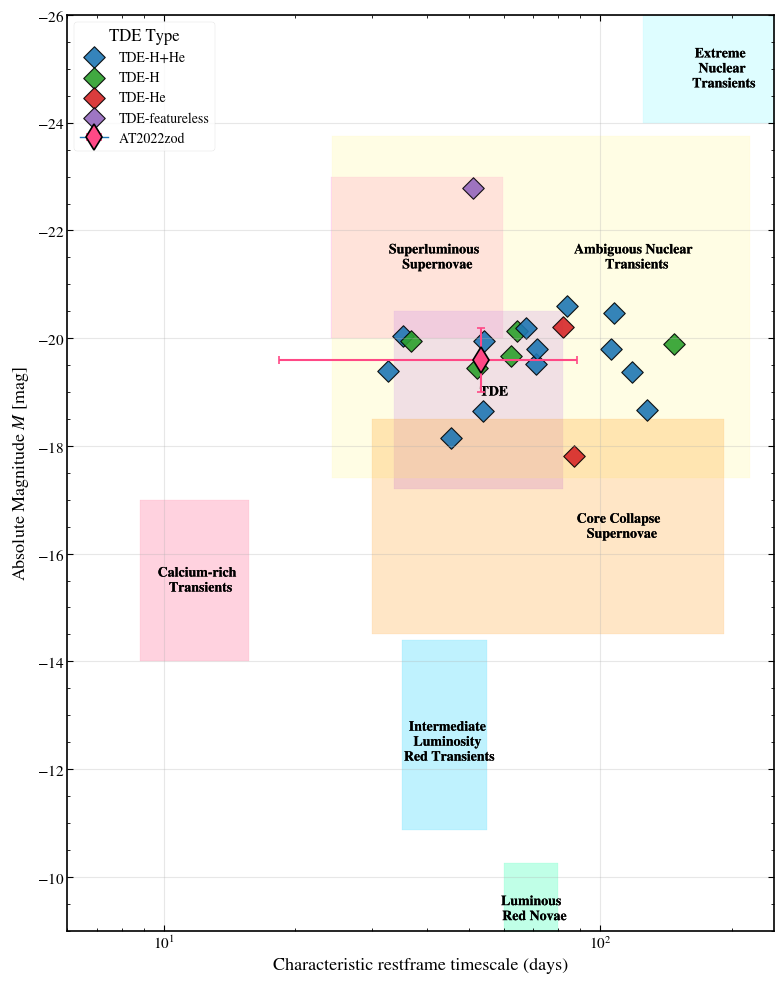

In [63]:
import matplotlib.cm as cm
import matplotlib.patheffects as pe
data_tde = pd.read_csv('rise_decay_Mabs2.csv', sep=';')
# Load data
df = pd.read_csv("fast_transients_summary.csv")

# --- Settings ---
plt.figure(figsize=(8,10))
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
# Define vaporwave-like colormap (you can tweak this)
cmap = cm.plasma  # or 'cool', 'magma', 'PuRd' for similar aesthetic
colors = cmap(np.linspace(0.2, 0.9, len(df)))

# # --- Plot each transient individually with its name in the legend ---
# for i, (idx, row) in enumerate(df.iterrows()):
#     plt.scatter(
#         row["t_rise_rf [days]"],
#         row["M [mag]"],
#         color=colors[i],
#         s=120,
#         marker="^",
#         edgecolor="black",
#         linewidth=0.8,
#         alpha=0.9,
#         label=row["Object Name"]
#     )


# --- Plot each transient individually with its name in the legend ---
# Color map for TDE spectral types
tde_colors = {
    'TDE-H+He': '#1f77b4',       # blue
    'TDE-H': '#2ca02c',          # green
    'TDE-He': '#d62728',         # red
    'TDE-featureless': '#9467bd' # purple
}

for i, (idx, row) in enumerate(data_tde.iterrows()):
    name_tde = row['IAU']
    M_abs_tde = row['M_abs']
    type_tde = row['Spec']
    rise_time_tde = row['rise_timescale'] + row['decay_timescale']

    color = tde_colors.get(type_tde, 'gray')  # default gray if not found

    plt.scatter(
        rise_time_tde,
        M_abs_tde,
        color=color,
        s=120,
        marker="D",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        label=type_tde
    )

# plt.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# plt.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# plt.scatter(
#     18.6484+34.7266, -20.5,
#     marker="*",
#     s=350,
#     color="gold",
#     edgecolor="black",
#     linewidth=1.0,
#     label="AT2022zod"
# )


# Make legend show unique entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="TDE Type")

# --- Add fictitious point ---


from matplotlib.colors import to_rgba
# Define vaporwave-like tones
c_slsn = to_rgba("#FF71CE", alpha=0.25)   # hot pink
c_ic   = to_rgba("#01CDFE", alpha=0.25)   # cyan blue
c_lrn  = to_rgba("#05FFA1", alpha=0.25)   # mint green
c_tde  = to_rgba("#B967FF", alpha=0.25)   # purple
c_ant  = to_rgba("#FFFB96", alpha=0.25)   # pastel yellow
c_ccsn = to_rgba("#FF9F1C", alpha=0.25)   # orange
c_crt  = to_rgba("#FF4F81", alpha=0.25)   # magenta
c_ent  = to_rgba("#7DF9FF", alpha=0.25)   # light cyan

# Helper for outlined text
outline = [pe.withStroke(linewidth=0.05, foreground='black')]

# # Superluminous Supernovae (SLSNe)
# plt.fill_betweenx(y=[-23, -20], x1=41.9-17.8, x2=41.9+17.8,
#                   color=c_slsn, zorder=0)
# plt.text(41.9, -21.5, "Superluminous \n Supernovae", ha='center', va='center',
#          fontsize=10, color="#FF71CE", weight='bold', path_effects=outline)

# # Intermediate Luminosity Red Transients
# plt.fill_betweenx(y=[-14.39, -10.87], x1=35, x2=55,
#                   color=c_ic, zorder=0)
# plt.text(45, -12.5, "Intermediate \nLuminosity \nRed Transients", ha='center', va='center',
#          fontsize=10, color="#01CDFE", weight='bold', path_effects=outline)

# # Luminous Red Novae
# plt.fill_betweenx(y=[-10.25, -8.5], x1=60, x2=80,
#                   color=c_lrn, zorder=0)
# plt.text(70, -9.4, "Luminous \n Red Novae", ha='center', va='center',
#          fontsize=10, color="#05FFA1", weight='bold', path_effects=outline)

# # Tidal Disruption Events
# plt.fill_betweenx(y=[-20.5, -17.2], x1=33.6, x2=82,
#                   color=c_tde, zorder=0)
# plt.text(57, -19.0, "TDE", ha='center', va='center',
#          fontsize=10, color="#B967FF", weight='bold', path_effects=outline)

# # Ambiguous Nuclear Transients
# plt.fill_betweenx(y=[-23.75, -17.40], x1=24.3, x2=220,
#                   color=c_ant, zorder=0)
# plt.text(120, -21.5, "Ambiguous Nuclear \n Transients", ha='center', va='center',
#          fontsize=10, color="#FFFB96", weight='bold', path_effects=outline)

# # Core Collapse Supernovae
# plt.fill_betweenx(y=[-18.5, -14.5], x1=30, x2=192,
#                   color=c_ccsn, zorder=0)
# plt.text(111, -16.5, "Core Collapse \n Supernovae", ha='center', va='center',
#          fontsize=10, color="#FF9F1C", weight='bold', path_effects=outline)

# # Calcium-rich Transients
# plt.fill_betweenx(y=[-17, -14], x1=8.80, x2=15.65,
#                   color=c_crt, zorder=0)
# plt.text(12, -15.5, "Calcium-rich \n Transients", ha='center', va='center',
#          fontsize=10, color="#FF4F81", weight='bold', path_effects=outline)

# # Extreme Nuclear Transients
# plt.fill_betweenx(y=[-26.9, -24], x1=125.25, x2=295,
#                   color=c_ent, zorder=0)
# plt.text(190, -25.0, "Extreme \n Nuclear \n Transients", ha='center', va='center',
#          fontsize=10, color="#7DF9FF", weight='bold', path_effects=outline)

# Superluminous Supernovae (SLSNe)
plt.fill_betweenx(y=[-23, -20], x1=41.9-17.8, x2=41.9+17.8,
                  color=c_slsn, zorder=0)
plt.text(41.9, -21.5, "Superluminous \n Supernovae", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Intermediate Luminosity Red Transients
plt.fill_betweenx(y=[-14.39, -10.87], x1=35, x2=55,
                  color=c_ic, zorder=0)
plt.text(45, -12.5, "Intermediate \nLuminosity \nRed Transients", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Luminous Red Novae
plt.fill_betweenx(y=[-10.25, -8.5], x1=60, x2=80,
                  color=c_lrn, zorder=0)
plt.text(70, -9.4, "Luminous \n Red Novae", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Tidal Disruption Events
plt.fill_betweenx(y=[-20.5, -17.2], x1=33.6, x2=82,
                  color=c_tde, zorder=0)
plt.text(57, -19.0, "TDE", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Ambiguous Nuclear Transients
plt.fill_betweenx(y=[-23.75, -17.40], x1=24.3, x2=220,
                  color=c_ant, zorder=0)
plt.text(120, -21.5, "Ambiguous Nuclear \n Transients", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Core Collapse Supernovae
plt.fill_betweenx(y=[-18.5, -14.5], x1=30, x2=192,
                  color=c_ccsn, zorder=0)
plt.text(111, -16.5, "Core Collapse \n Supernovae", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Calcium-rich Transients
plt.fill_betweenx(y=[-17, -14], x1=8.80, x2=15.65,
                  color=c_crt, zorder=0)
plt.text(12, -15.5, "Calcium-rich \n Transients", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)

# Extreme Nuclear Transients
plt.fill_betweenx(y=[-26.9, -24], x1=125.25, x2=295,
                  color=c_ent, zorder=0)
plt.text(190, -25.0, "Extreme \n Nuclear \n Transients", ha='center', va='center',
         fontsize=10, color="k", weight='bold', path_effects=outline)



# Professional axis and grid styling
plt.xlabel("Characteristic restframe timescale (days)", fontsize=13)
plt.ylabel("Absolute Magnitude $M$ [mag]", fontsize=13)

plt.ylim(-9, -26)
plt.xlim(6, 250)
plt.xscale('log')

# Denser y-ticks and reversed axis direction preserved
#plt.yticks(range(-26, -8, 1))

# Improved grid aesthetics
plt.grid(True, alpha=0.3)
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True, length=4)
plt.tick_params(which='minor', length=2)

# Frame thickness for publication quality
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig('ztfFP_at2022zod_timescale',dpi=300)
plt.show()

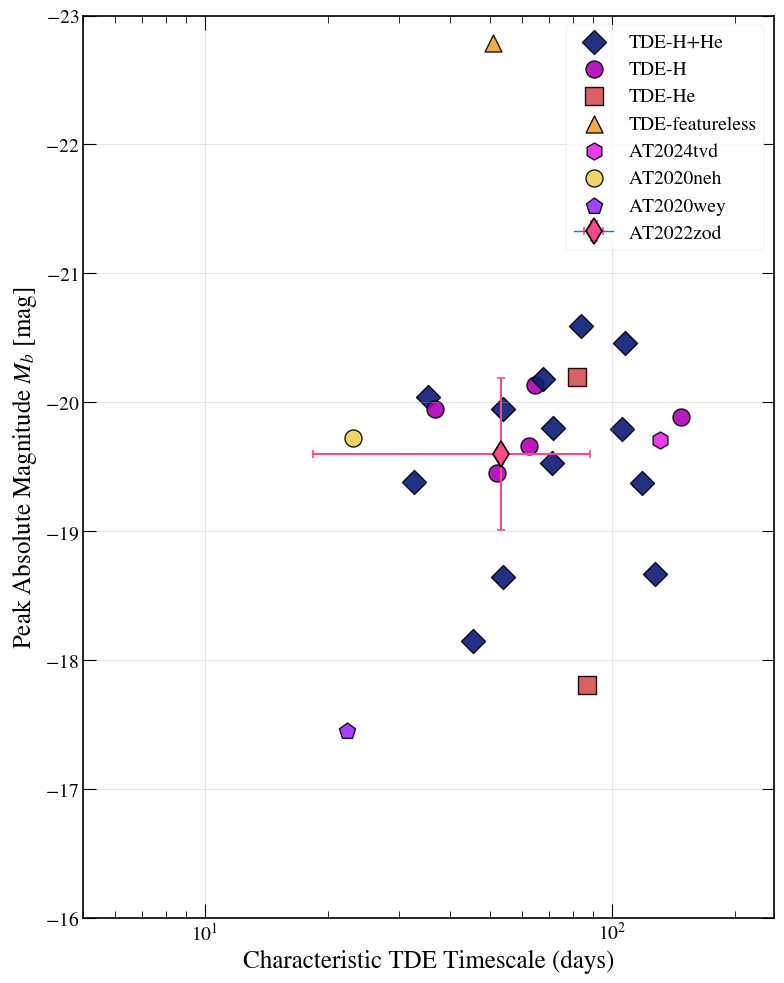

In [65]:
import matplotlib.cm as cm
import matplotlib.patheffects as pe
# Load data
df = pd.read_csv("fast_transients_summary.csv")

# --- Settings ---
plt.figure(figsize=(8,10))
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# --- Plot each transient individually with its name in the legend ---
# Color map for TDE spectral types
tde_styles = {
    "TDE-H+He": {"marker": "D", "color": "#0B1A78"},      # diamond, dark blue
    "TDE-H": {"marker": "o", "color": "#B000B7"},         # circle, purple/magenta
    "TDE-He": {"marker": "s", "color": "#D54F52"},        # square, red-pink
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}# triangle, orange
}

# track which labels have been added (to avoid duplicate legend entries)
used_labels = set()

for i, (idx, row) in enumerate(data_tde.iterrows()):
    name_tde = row['IAU']
    M_abs_tde = row['M_abs']
    type_tde = row['Spec']
    rise_time_tde = row['rise_timescale'] + row['decay_timescale']

    # get marker + color; fall back to gray circle if missing
    style = tde_styles.get(type_tde, {"marker": "o", "color": "gray"})

    # add label only once
    label = type_tde if type_tde not in used_labels else None
    used_labels.add(type_tde)

    plt.scatter(
        rise_time_tde,
        M_abs_tde,
        s=150,
        marker=style["marker"],
        color=style["color"],
        edgecolor="black",
        linewidth=1.0,
        alpha=0.9,
        label=label
    )

plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')



sn_data = {
    'AT2024tvd': {'M_abs': -19.71, 'rise': 10.21, 'decay': 120.719},
    'AT2020neh': {'M_abs': -19.72, 'rise': 3.47, 'decay': 19.66},
    'AT2020wey': {'M_abs': -17.450157, 'rise':11.944388,  'decay': 10.414770},
}

styles = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"},
    "AT2020wey": {"marker": "p", "color": "#9C2BFF"},
}
# AT2020wey	0.000233	59154.952723	11.944388	10.414770	9.63	0.22	0.18	TD

for name, vals in sn_data.items():
    duration = vals['rise'] + vals['decay']
    
    m = styles[name]["marker"]
    c = styles[name]["color"]
    
    plt.scatter(
        duration,
        vals['M_abs'],
        color=c,
        s=150,
        marker=m,
        edgecolor='black',
        linewidth=1.0,
        alpha=0.9,
        label=name
    )



# Make legend show unique entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),fontsize=14)




# Professional axis and grid styling
plt.xlabel("Characteristic TDE Timescale (days)", fontsize=18)
plt.ylabel("Peak Absolute Magnitude $M_b$ [mag]", fontsize=18)

plt.ylim(-16, -23)
plt.xlim(5, 250)
plt.xscale('log')

# Denser y-ticks and reversed axis direction preserved
#plt.yticks(range(-26, -8, 1))
plt.tick_params(axis='x', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='x', which='both',direction='in',right='on', top='on')
plt.tick_params(axis='x', which='major', length=10)        # To set tick size
plt.tick_params(axis='x', which='minor', length=5)
plt.tick_params(axis='y', which='major', labelsize=14)    # To set tick label fontsize
plt.tick_params(axis='y', which='major', length=9)        # To set tick size
plt.tick_params(axis='y', which='minor', length=4.5)      # To set tick size
plt.tick_params(axis='y', which='both',direction='in',right='on', top='on')
# # Improved grid aesthetics
plt.grid(True, alpha=0.3)
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True, length=4)
# plt.tick_params(which='minor', length=2)

# Frame thickness for publication quality
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
#plt.savefig('TDE_timescale.png',dpi=300)
plt.show()

# Host Mass plot

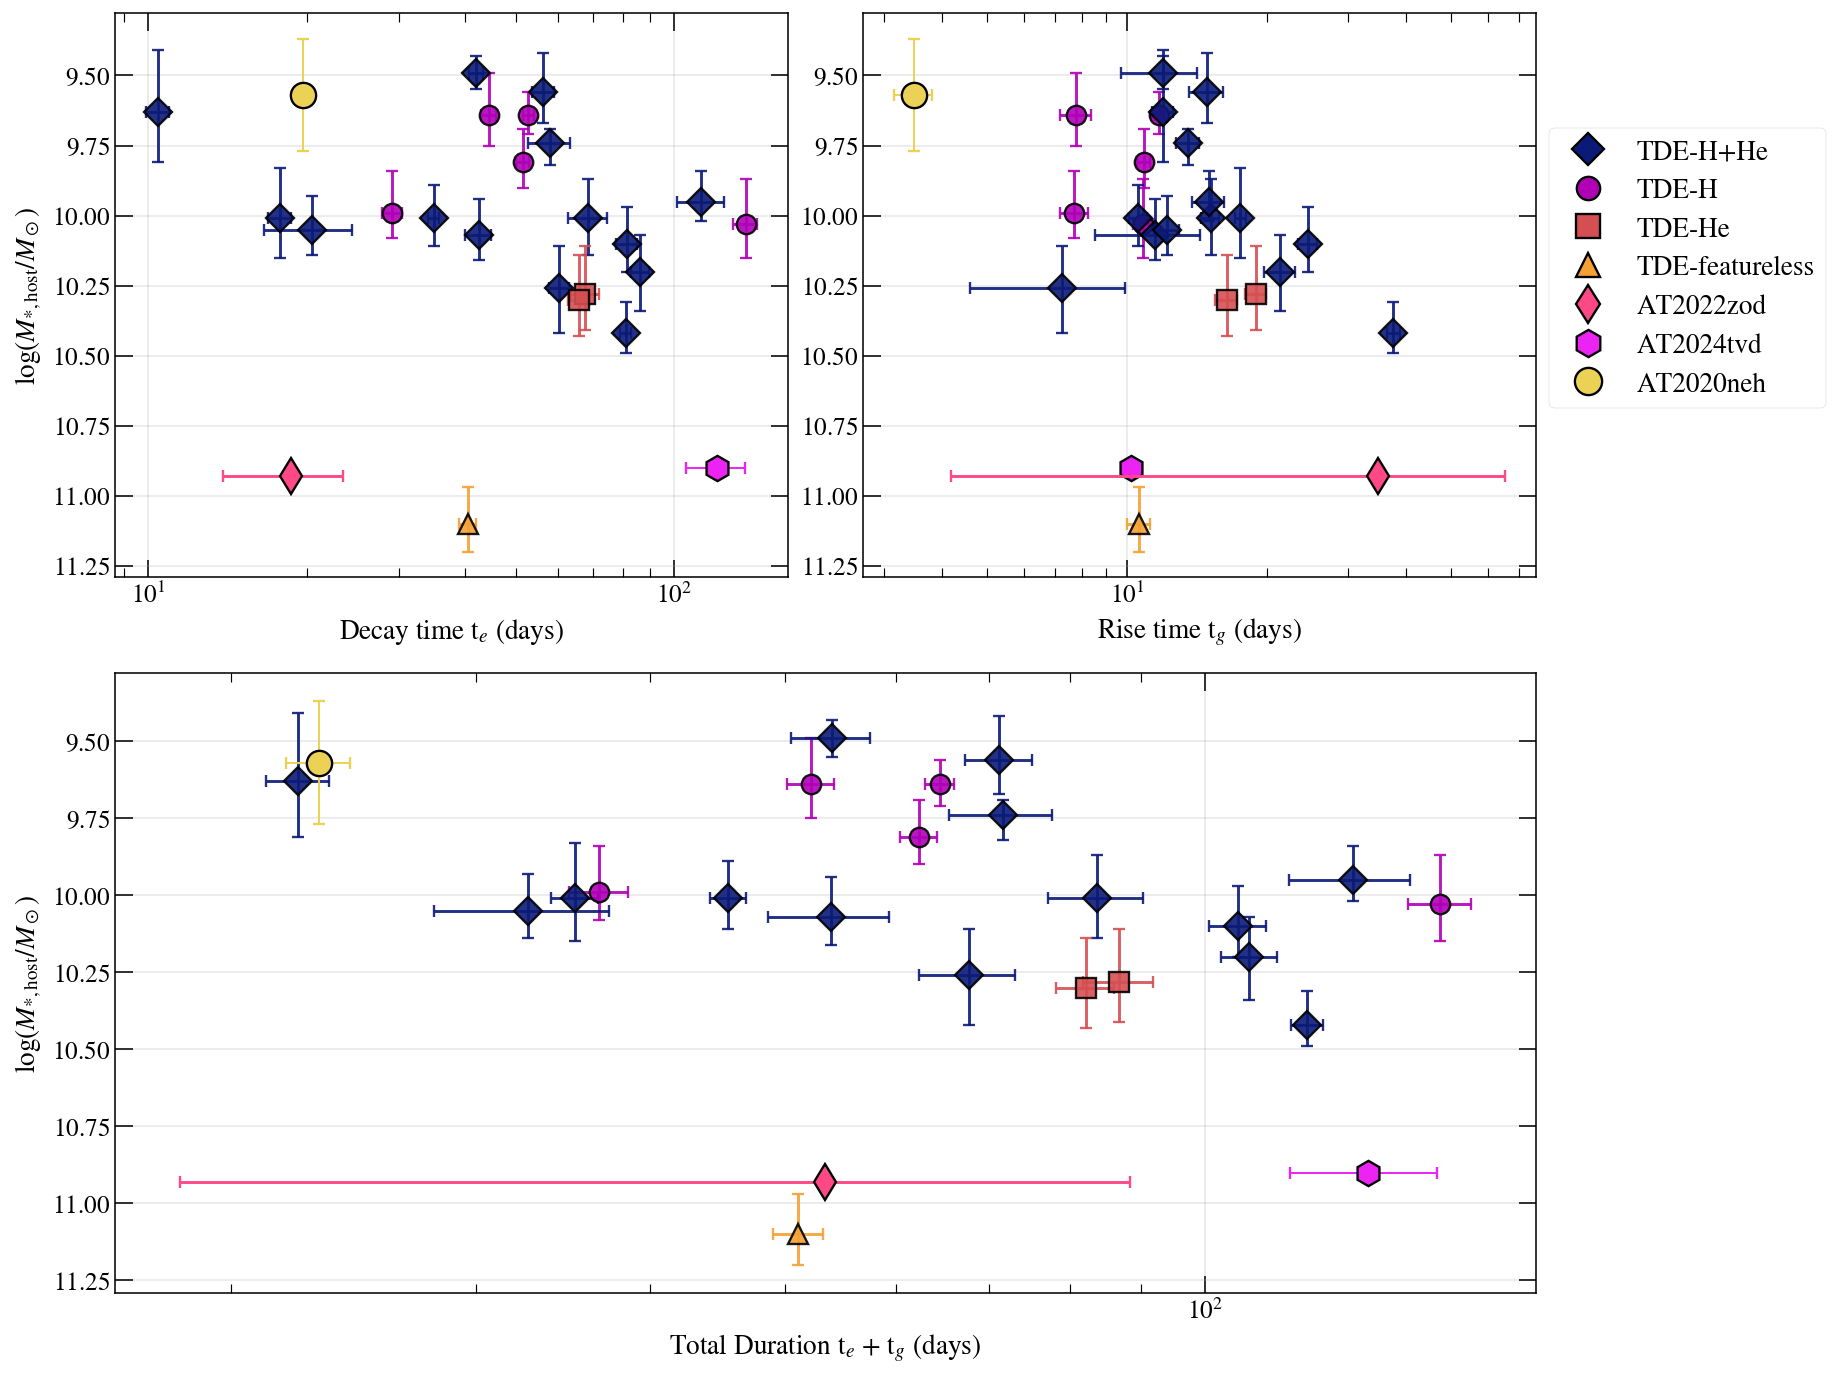

In [69]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA (same for all panels)
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "logM"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "logM"])

# Ensure uncertainty columns exist
if "rise_timescale_err" not in df_rise.columns:
    df_rise = df_rise.merge(df_all[["IAU", "rise_timescale_err"]], on="IAU", how="left")
if "decay_timescale_err" not in df_decay.columns:
    df_decay = df_decay.merge(df_all[["IAU", "decay_timescale_err"]], on="IAU", how="left")

# ============================================================
# TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},
    "TDE-H":           {"marker": "o", "color": "#B000B7"},
    "TDE-He":          {"marker": "s", "color": "#D54F52"},
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}
}

special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986"},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4"},
    "AT2020neh": {"marker": "o", "color": "#EBD155"}
}

# ============================================================
# FIGURE LAYOUT (2 rows, 2 cols; bottom spans both)
# ============================================================
fig = plt.figure(figsize=(13, 10), dpi=140)

# Grid:
# ┌───────────────┬───────────────┐
# │   Decay       │    Rise        │
# ├───────────────┴───────────────┤
# │          Duration              │
# └────────────────────────────────┘

gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_decay = fig.add_subplot(gs[0, 0])
ax_rise  = fig.add_subplot(gs[0, 1])
ax_dur   = fig.add_subplot(gs[1, :])

# ============================================================
# 1) DECAY PANEL
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_decay.errorbar(
        group["decay_timescale"],
        group["logM"],
        xerr=group["decay_timescale_err"],
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )


# plt.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
# plt.errorbar(34.7266, -19.598, marker="d",xerr=30.56,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')
#plt.errorbar(18.6484+34.7266, -19.598, marker="d",xerr=35,yerr=0.59, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')

# Add special objects
# ax_decay.errorbar(15.44, 10.93, xerr=2.38, marker='d', mfc="#FF4986",
#                   mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)
ax_decay.errorbar(18.6484,  10.93, marker="d",xerr=4.77, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5)


ax_decay.errorbar(120.719, 10.9, xerr=15.43,yerr=0.02, marker='h', mfc="#EB24F4",
                  mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)

ax_decay.errorbar(19.66, 9.57, xerr=0.90,yerr=0.2, marker='o', mfc="#EBD155",
                  mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_decay.set_xscale("log")
ax_decay.set_ylabel(r"$\log(M_{*,\mathrm{host}}/M_\odot)$", fontsize=14)
ax_decay.set_xlabel(r"Decay time t$_e$ (days)", fontsize=14)
ax_decay.invert_yaxis()
ax_decay.grid(alpha=0.3)

# formatting
ax_decay.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_decay.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)


# ============================================================
# 2) RISE PANEL
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_rise.errorbar(
        group["rise_timescale"],
        group["logM"],
        xerr=group["rise_timescale_err"],
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Add special objects
# ax_rise.errorbar(13.24, 10.93, xerr=3.68, marker='d', mfc="#FF4986",
#                  mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)
ax_rise.errorbar(34.7266, 10.93, marker="d",xerr=30.56, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')

ax_rise.errorbar(10.21, 10.9, xerr=0.34,yerr=0.02, marker='h', mfc="#EB24F4",
                 mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)
ax_rise.errorbar(3.47,  9.57, xerr=0.33,yerr=0.2, marker='o', mfc="#EBD155",
                 mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_rise.set_xscale("log")
ax_rise.set_xlabel(r"Rise time t$_g$ (days)", fontsize=14)
ax_rise.invert_yaxis()
ax_rise.grid(alpha=0.3)

ax_rise.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_rise.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)


# ============================================================
# 3) DURATION PANEL (t_e + t_g)
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_dur.errorbar(
        group["rise_timescale"] + group["decay_timescale"],
        group["logM"],
        xerr=group["rise_timescale_err"] + group["decay_timescale_err"],
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Add special objects
# ax_dur.errorbar(13.24+15.44, 10.93, xerr=3.68+2.38, marker='d',
#                 mfc="#FF4986", mec='black', mew=1.2, ecolor="#FF4986", markersize=13, capsize=3)
ax_dur.errorbar(18.6484+34.7266, 10.93, marker="d",xerr=35, mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5,label='AT2022zod')

ax_dur.errorbar(10.21+120.719, 10.9, xerr=0.34+15.43,yerr=0.02, marker='h',
                mfc="#EB24F4", mec='black', mew=1.2, ecolor="#EB24F4", markersize=13, capsize=3)
ax_dur.errorbar(3.47+19.66,  9.57, xerr=0.33+0.90,yerr=0.2, marker='o',
                mfc="#EBD155", mec='black', mew=1.2, ecolor="#EBD155", markersize=13, capsize=3)

ax_dur.set_xscale("log")
ax_dur.set_xlabel(r"Total Duration t$_e$ + t$_g$ (days)", fontsize=14)
ax_dur.set_ylabel(r"$\log(M_{*,\mathrm{host}}/M_\odot)$", fontsize=14)
ax_dur.invert_yaxis()
ax_dur.grid(alpha=0.3)

ax_dur.tick_params(axis='both', which='major', labelsize=13, length=9, direction='in', top=True, right=True)
ax_dur.tick_params(axis='both', which='minor', length=4.5, direction='in', top=True, right=True)

# ============================================================
# SHARED LEGEND (placed on the right)
# ============================================================
legend_elements = []

for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=style["marker"],
               color="white",
               markerfacecolor=style["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=12,
               label=subtype)
    )

for name, info in special_points.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=info["marker"],
               color="white",
               markerfacecolor=info["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=14,
               label=name)
    )

fig.legend(
    handles=legend_elements,
    fontsize=14,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    loc="center left",
    bbox_to_anchor=(0.85, 0.8)
)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # leave space for the legend
plt.savefig('ztfFP_all_tde_timescale_Mhost.png',dpi=400)
plt.show()


# Mhost peak x Mhost duration 

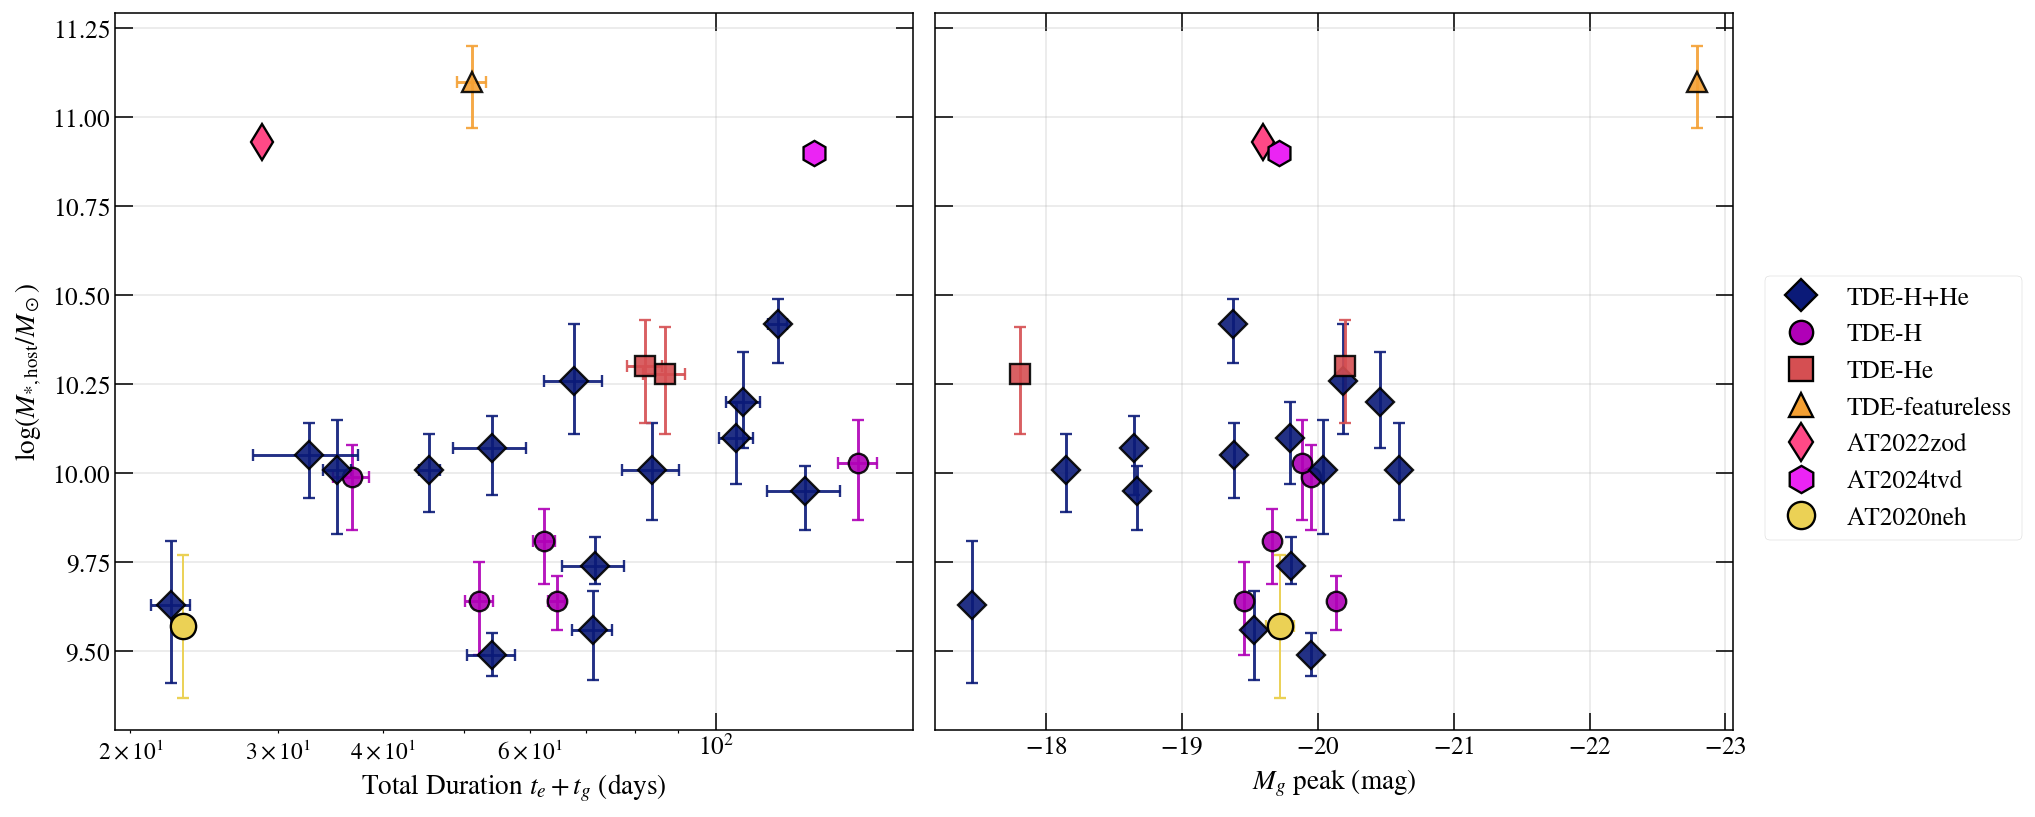

In [72]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "logM", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "logM", "M_abs"])

# Ensure uncertainty columns exist
for col, col_err in [("rise_timescale", "rise_timescale_err"),
                     ("decay_timescale", "decay_timescale_err"),
                     ("logM", "logM_err_low")]:
    if col_err not in df_rise.columns:
        if col_err in df_all.columns:
            df_rise = df_rise.merge(df_all[["IAU", col_err]], on="IAU", how="left")
    if col_err not in df_decay.columns:
        if col_err in df_all.columns:
            df_decay = df_decay.merge(df_all[["IAU", col_err]], on="IAU", how="left")

# Duration
df_rise["duration"] = df_rise["rise_timescale"] + df_rise["decay_timescale"]

# ============================================================
# TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},
    "TDE-H":           {"marker": "o", "color": "#B000B7"},
    "TDE-He":          {"marker": "s", "color": "#D54F52"},
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}
}
#ax_decay.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5)

special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986", "logM": 10.93, "Mabs": -19.59846722939633},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4", "logM": 10.90, "Mabs": -19.71},
    "AT2020neh": {"marker": "o", "color": "#EBD155", "logM":  9.57, "Mabs": -19.72}
}

# Special durations
spec_times = {
    "AT2022zod": 13.24 + 15.44,
    "AT2024tvd": 10.21 + 120.719,
    "AT2020neh":  3.47 + 19.66,
}

# ============================================================
# FIGURE LAYOUT (1 ROW, 2 COLS, SHARED Y AXIS)
# ============================================================
fig, (ax_dur, ax_mag) = plt.subplots(
    1, 2, figsize=(14, 6), dpi=140, sharey=True
)

# ============================================================
# 1) LEFT PANEL: Duration vs Mhost
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_dur.errorbar(
        group["duration"],
        group["logM"],
        xerr=group["rise_timescale_err"] + group["decay_timescale_err"],
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Special objects – Duration
for name, info in special_points.items():
    ax_dur.errorbar(
        spec_times[name],
        info["logM"],
        xerr=0,  # if you want errors, add them here
        yerr=0.02 if name == "AT2024tvd" else 0.20 if name == "AT2020neh" else None,
        marker=info["marker"],
        mfc=info["color"],
        mec="black",
        mew=1.2,
        ecolor=info["color"],
        markersize=13,
        capsize=3,
    )

ax_dur.set_xscale("log")
ax_dur.set_xlabel(r"Total Duration $t_e + t_g$ (days)", fontsize=14)
ax_dur.set_ylabel(r"$\log(M_{*,\mathrm{host}}/M_\odot)$", fontsize=14)
#ax_dur.invert_yaxis()
ax_dur.grid(alpha=0.3)
ax_dur.tick_params(axis='both', which='major', labelsize=13, length=9,
                   direction='in', top=True, right=True)


# ============================================================
# 2) RIGHT PANEL: M_g peak vs Mhost
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_mag.errorbar(
        group["M_abs"],
        group["logM"],
        xerr=group["M_abs_err"] if "M_abs_err" in group else None,
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Special events – Peak magnitude
for name, info in special_points.items():
    ax_mag.errorbar(
        info["Mabs"],
        info["logM"],
        xerr=0.1 if name == "AT2020neh" else 0.02,   # add your real Mabs errors later
        yerr=0.02 if name == "AT2024tvd" else 0.20 if name == "AT2020neh" else None,
        marker=info["marker"],
        mfc=info["color"],
        mec="black",
        mew=1.2,
        ecolor=info["color"],
        markersize=13,
        capsize=3,
    )

ax_mag.set_xlabel(r"$M_g$ peak (mag)", fontsize=14)
ax_mag.invert_xaxis()
ax_mag.grid(alpha=0.3)
ax_mag.tick_params(axis='both', which='major', labelsize=13, length=9,
                   direction='in', top=True, right=True)


# ============================================================
# SHARED LEGEND (outside right)
# ============================================================
legend_elements = []

# TDE types
for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=style["marker"],
               color="white",
               markerfacecolor=style["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=12,
               label=subtype)
    )

# Special events
for name, info in special_points.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=info["marker"],
               color="white",
               markerfacecolor=info["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=14,
               label=name)
    )

fig.legend(
    handles=legend_elements,
    fontsize=13,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    loc="center left",
    bbox_to_anchor=(0.90, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(right=0.89)
plt.savefig('ZTFFP_MhostxDuration_Mgpeak.pdf', dpi=400,bbox_inches="tight")
plt.show()


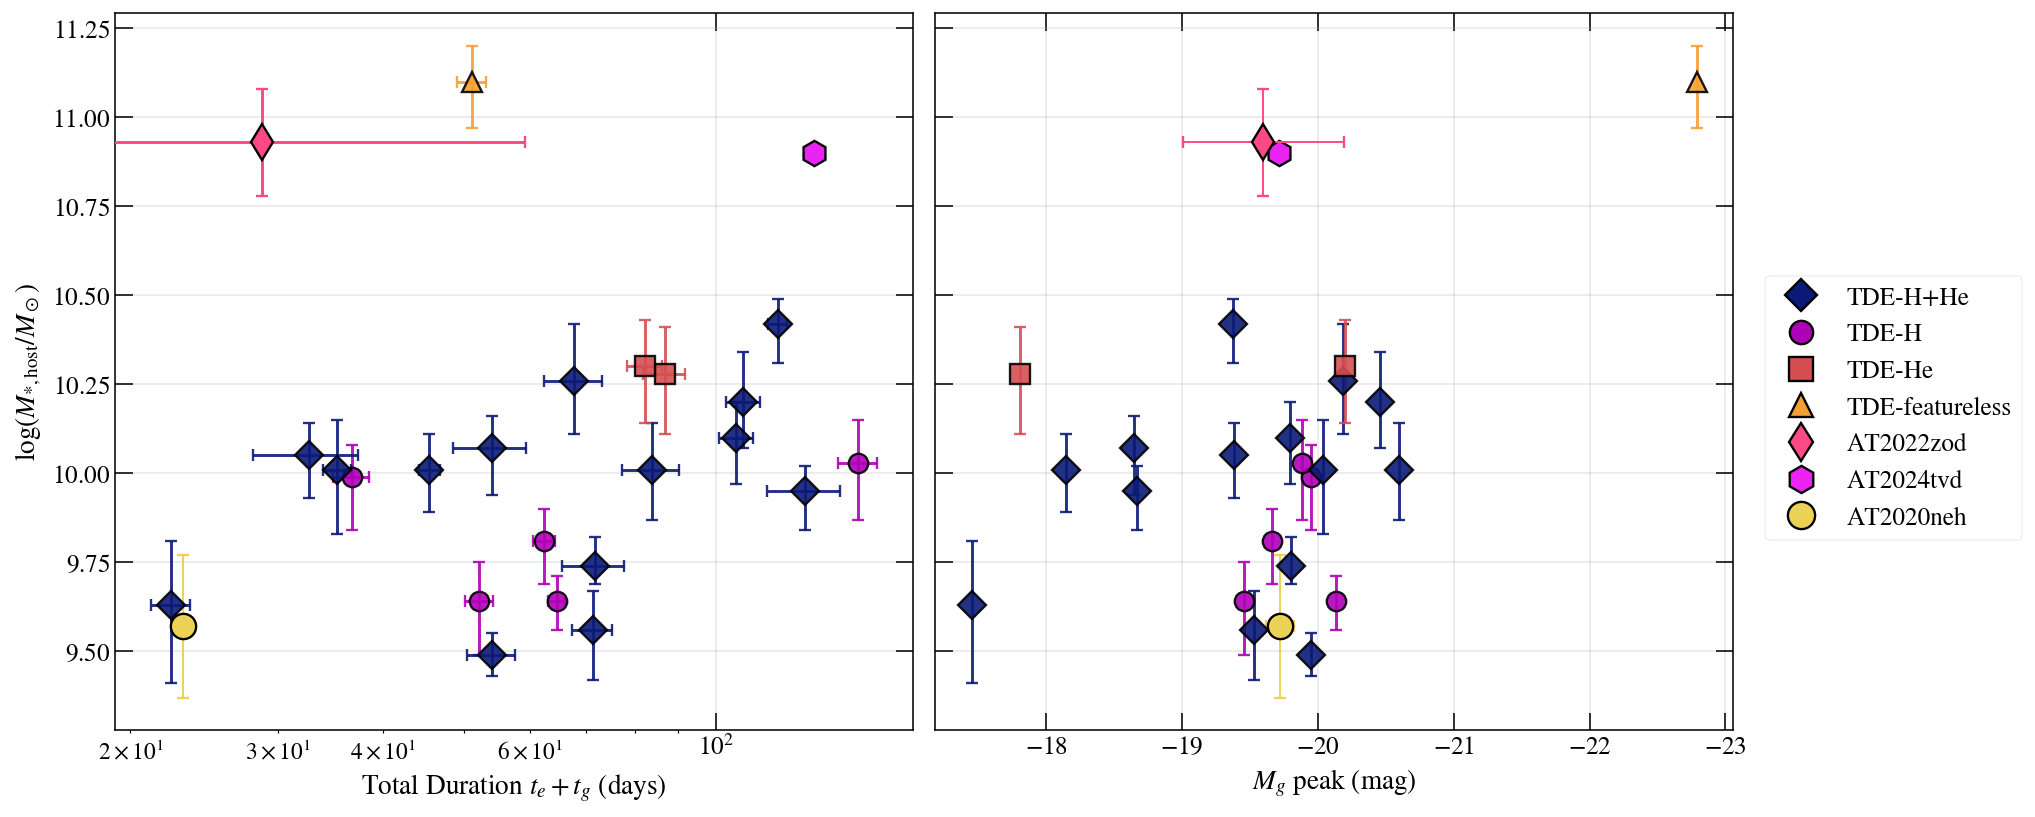

In [77]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# PREPARE DATA
# ============================================================
df_rise = df_with_abs.dropna(subset=["rise_timescale", "logM", "M_abs"])
df_decay = df_with_abs.dropna(subset=["decay_timescale", "logM", "M_abs"])

# Ensure uncertainty columns exist
for col, col_err in [("rise_timescale", "rise_timescale_err"),
                     ("decay_timescale", "decay_timescale_err"),
                     ("logM", "logM_err_low")]:
    if col_err not in df_rise.columns:
        if col_err in df_all.columns:
            df_rise = df_rise.merge(df_all[["IAU", col_err]], on="IAU", how="left")
    if col_err not in df_decay.columns:
        if col_err in df_all.columns:
            df_decay = df_decay.merge(df_all[["IAU", col_err]], on="IAU", how="left")

# Duration
df_rise["duration"] = df_rise["rise_timescale"] + df_rise["decay_timescale"]

# ============================================================
# TDE STYLES
# ============================================================
tde_styles = {
    "TDE-H+He":        {"marker": "D", "color": "#0B1A78"},
    "TDE-H":           {"marker": "o", "color": "#B000B7"},
    "TDE-He":          {"marker": "s", "color": "#D54F52"},
    "TDE-featureless": {"marker": "^", "color": "#F4A033"}
}
#ax_decay.errorbar(18.6484,  -19.59846722939633, marker="d",xerr=4.77, yerr=0.59,mfc="#FF4986", mec="black",mew=1.2,ecolor= "#FF4986", zorder=500,capsize=3,markersize=13,elinewidth=1.5)

special_points = {
    "AT2022zod": {"marker": "d", "color": "#FF4986", "logM": 10.93, "Mabs": -19.59846722939633},
    "AT2024tvd": {"marker": "h", "color": "#EB24F4", "logM": 10.90, "Mabs": -19.71},
    "AT2020neh": {"marker": "o", "color": "#EBD155", "logM":  9.57, "Mabs": -19.72}
}

# Special durations
spec_times = {
    "AT2022zod": 13.24 + 15.44,
    "AT2024tvd": 10.21 + 120.719,
    "AT2020neh":  3.47 + 19.66,
}

# ============================================================
# FIGURE LAYOUT (1 ROW, 2 COLS, SHARED Y AXIS)
# ============================================================
fig, (ax_dur, ax_mag) = plt.subplots(
    1, 2, figsize=(14, 6), dpi=140, sharey=True
)

# ============================================================
# 1) LEFT PANEL: Duration vs Mhost
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_dur.errorbar(
        group["duration"],
        group["logM"],
        xerr=group["rise_timescale_err"] + group["decay_timescale_err"],
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Special objects – Duration
for name, info in special_points.items():
    if name == "AT2022zod":
        continue
    ax_dur.errorbar(
        spec_times[name],
        info["logM"],
        xerr=0,  # if you want errors, add them here
        yerr=0.02 if name == "AT2024tvd" else 0.20 if name == "AT2020neh" else None,
        marker=info["marker"],
        mfc=info["color"],
        mec="black",
        mew=1.2,
        ecolor=info["color"],
        markersize=13,
        capsize=3,
    )

# ------------------------------------------------------------
# AT2022zod — EXPLICIT, SEPARATE, WITH UNCERTAINTIES
# ------------------------------------------------------------
zod_duration = 13.24 + 15.44
zod_duration_err = np.sqrt(4.77**2 + 30.0**2)
zod_logM = 10.93
zod_logM_err = 0.15

ax_dur.errorbar(
    zod_duration,
    zod_logM,
    xerr=zod_duration_err,
    yerr=zod_logM_err,
    marker="d",
    linestyle="none",
    mfc="#FF4986",
    mec="black",
    mew=1.2,
    ecolor="#FF4986",
    markersize=13,
    capsize=3,
    elinewidth=1.5,
    zorder=600
)

ax_dur.set_xscale("log")
ax_dur.set_xlabel(r"Total Duration $t_e + t_g$ (days)", fontsize=14)
ax_dur.set_ylabel(r"$\log(M_{*,\mathrm{host}}/M_\odot)$", fontsize=14)
#ax_dur.invert_yaxis()
ax_dur.grid(alpha=0.3)
ax_dur.tick_params(axis='both', which='major', labelsize=13, length=9,
                   direction='in', top=True, right=True)


# ============================================================
# 2) RIGHT PANEL: M_g peak vs Mhost
# ============================================================
for subtype, group in df_rise.groupby("Spec"):
    style = tde_styles.get(subtype, {"marker": "o", "color": "gray"})
    ax_mag.errorbar(
        group["M_abs"],
        group["logM"],
        xerr=group["M_abs_err"] if "M_abs_err" in group else None,
        yerr=[group["logM_err_low"], group["logM_err_high"]],
        linestyle="none",
        marker=style["marker"],
        mfc=style["color"],
        mec="black",
        mew=1.2,
        ecolor=style["color"],
        markersize=10,
        capsize=3,
        elinewidth=1.5,
        alpha=0.9,
    )

# Special events – Peak magnitude
for name, info in special_points.items():
    if name == "AT2022zod":
        continue
    ax_mag.errorbar(
        info["Mabs"],
        info["logM"],
        xerr=0.1 if name == "AT2020neh" else 0.02,   # add your real Mabs errors later
        yerr=0.02 if name == "AT2024tvd" else 0.20 if name == "AT2020neh" else None,
        marker=info["marker"],
        mfc=info["color"],
        mec="black",
        mew=1.2,
        ecolor=info["color"],
        markersize=13,
        capsize=3,
    )
    
ax_mag.errorbar(
    -19.59846722939633,
    zod_logM,
    xerr=0.59,
    yerr=zod_logM_err,
    marker="d",
    linestyle="none",
    mfc="#FF4986",
    mec="black",
    mew=1.2,
    ecolor="#FF4986",
    markersize=13,
    capsize=3,
    zorder=600
)
ax_mag.set_xlabel(r"$M_g$ peak (mag)", fontsize=14)
ax_mag.invert_xaxis()
ax_mag.grid(alpha=0.3)
ax_mag.tick_params(axis='both', which='major', labelsize=13, length=9,
                   direction='in', top=True, right=True)


# ============================================================
# SHARED LEGEND (outside right)
# ============================================================
legend_elements = []

# TDE types
for subtype, style in tde_styles.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=style["marker"],
               color="white",
               markerfacecolor=style["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=12,
               label=subtype)
    )

# Special events
for name, info in special_points.items():
    legend_elements.append(
        Line2D([0], [0],
               marker=info["marker"],
               color="white",
               markerfacecolor=info["color"],
               markeredgecolor="black",
               markeredgewidth=1.2,
               linestyle="none",
               markersize=14,
               label=name)
    )

fig.legend(
    handles=legend_elements,
    fontsize=13,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    loc="center left",
    bbox_to_anchor=(0.90, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(right=0.89)
plt.savefig('ZTFFP_MhostxDuration_Mgpeak.pdf', dpi=400,bbox_inches="tight")
plt.show()
